# 08 — Volterra and Fractional Solvers

Companion notebook for the [`volterra` documentation page](https://optimiz-r.readthedocs.io/en/latest/algorithms/volterra.html).

This notebook follows the depth and structure of
`03_optimal_control_tutorial.ipynb`. Each section opens with a precise
mathematical reminder (definition, theorem, derivation), validates the
corresponding `optimizr` primitive against an analytic ground truth, runs a
convergence study where relevant, and ends with a concrete physical
application.

The four CPU-only Rust primitives demonstrated are:

1. `solve_fractional_ode` — Caputo fractional Adams predictor–corrector
   (Diethelm–Ford–Freed 2002).
2. `geometric_grid_lift` — multi-exponential Markovian lift of a
   convolution kernel (Abi Jaber–El Euch 2019).
3. `solve_volterra` — generic second-kind Volterra integral equation by
   product trapezoidal rule.
4. `fourier_invert` — recovery of a probability density from its
   characteristic function via discrete cosine/sine transform.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
from scipy.special import gamma as Gamma

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

rng = np.random.default_rng(0)
errors = {}
print('volterra notebook ready.')


volterra notebook ready.


## 1. Fractional calculus and the Caputo derivative

### Definitions

For $\alpha \in (0, 1)$ and a sufficiently regular function $h : [0, T] \to
\mathbb{R}$, the **Caputo fractional derivative** is

$$
D^\alpha h(t) \;=\; \frac{1}{\Gamma(1 - \alpha)} \int_0^t \frac{h'(s)}{(t - s)^\alpha}\, ds.
$$

It interpolates between the ordinary derivative ($\alpha \to 1$) and a
non-local memory operator. The associated **Cauchy problem**

$$
D^\alpha h(t) \;=\; F(t, h(t)), \qquad h(0) = h_0,
$$

is equivalent to the Volterra integral equation

$$
h(t) \;=\; h_0 + \frac{1}{\Gamma(\alpha)} \int_0^t (t - s)^{\alpha - 1}\, F(s, h(s))\, ds.
$$

### Mittag-Leffler closed form

For the linear test problem $D^\alpha h = -h$, $h(0) = 1$, the unique
solution is the **Mittag-Leffler function** of order $\alpha$:

$$
E_\alpha(z) \;=\; \sum_{k=0}^\infty \frac{z^k}{\Gamma(\alpha k + 1)}, \qquad
h(t) = E_\alpha(-t^\alpha).
$$

It generalises the exponential ($\alpha = 1 \Rightarrow E_1(z) = e^z$) and
exhibits a **slow algebraic tail** $E_\alpha(-t^\alpha) \sim
\frac{t^{-\alpha}}{\Gamma(1 - \alpha)}$ as $t \to \infty$ — the signature of
*sub-exponential relaxation*.

### Adams predictor–corrector (Diethelm–Ford–Freed 2002)

On a uniform grid $t_n = n \Delta t$, the predictor

$$
h^P_{n+1} \;=\; h_0 + \frac{\Delta t^\alpha}{\Gamma(\alpha + 1)} \sum_{k=0}^n
\big[ (n + 1 - k)^\alpha - (n - k)^\alpha \big]\, F(t_k, h_k),
$$

and the corrector

$$
h_{n+1} \;=\; h_0 + \frac{\Delta t^\alpha}{\Gamma(\alpha + 2)}
\Big[ F(t_{n+1}, h^P_{n+1}) + \sum_{k=0}^n a_{n+1,k}\, F(t_k, h_k) \Big],
$$

deliver an order $\min(2, 1 + \alpha)$ approximation. The history sum
explicitly encodes the **memory** intrinsic to fractional dynamics, hence
the higher per-step cost compared to a Markovian Runge–Kutta integrator.


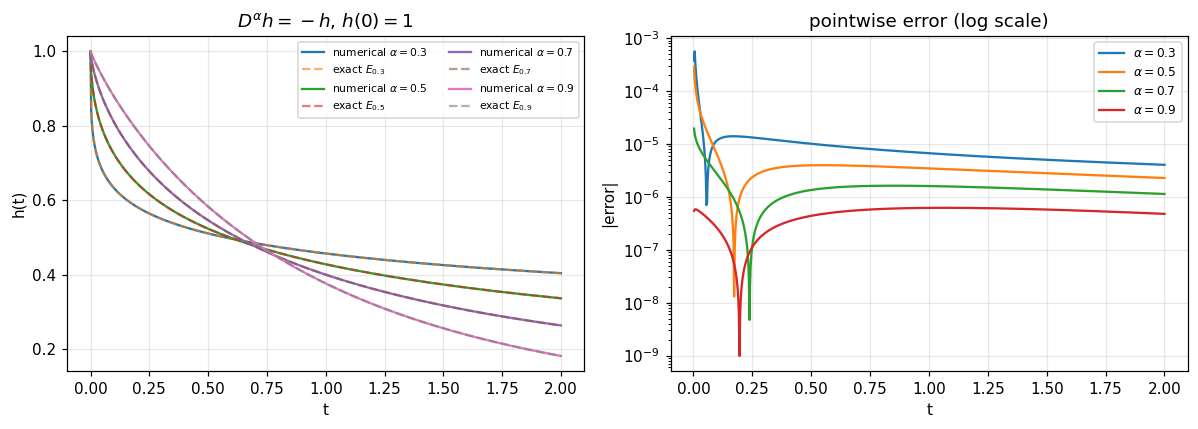

max error vs Mittag-Leffler = 5.625e-04


In [2]:
def mittag_leffler(alpha, z, n_terms=200):
    z = np.asarray(z, dtype=float)
    out = np.zeros_like(z)
    term = np.ones_like(z)
    for k in range(n_terms):
        out = out + term / Gamma(alpha * k + 1.0)
        term = term * z
    return out


T, N = 2.0, 800
alphas = [0.3, 0.5, 0.7, 0.9]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
max_err = 0.0
for a in alphas:
    res = opt.solve_fractional_ode(1.0, a, T, N, lambda t, h: -h)
    t = np.asarray(res['t_grid']); h_num = np.asarray(res['h'])
    h_exact = mittag_leffler(a, -t**a)
    err = np.max(np.abs(h_num - h_exact))
    max_err = max(max_err, err)
    axes[0].plot(t, h_num, label=rf'numerical $\alpha={a}$')
    axes[0].plot(t, h_exact, '--', alpha=0.6, label=f'exact $E_{{{a}}}$')
    axes[1].semilogy(t[1:], np.abs(h_num - h_exact)[1:], label=rf'$\alpha={a}$')
axes[0].set_xlabel('t'); axes[0].set_ylabel('h(t)')
axes[0].legend(fontsize=7, ncol=2); axes[0].set_title(r'$D^\alpha h = -h$, $h(0)=1$')
axes[1].set_xlabel('t'); axes[1].set_ylabel('|error|')
axes[1].legend(fontsize=8); axes[1].set_title('pointwise error (log scale)')
plt.tight_layout(); plt.show()
errors['fractional_ode_max_err'] = max_err
print(f'max error vs Mittag-Leffler = {max_err:.3e}')
assert max_err < 5e-2


### Convergence study in $\Delta t$ (sub-diffusive case $\alpha = 0.5$)

The fractional Adams scheme is provably of order $\min(2, 1 + \alpha)$. For
$\alpha = 0.5$ we therefore expect a slope of $-3/2$ in a $\log$–$\log$
error plot.


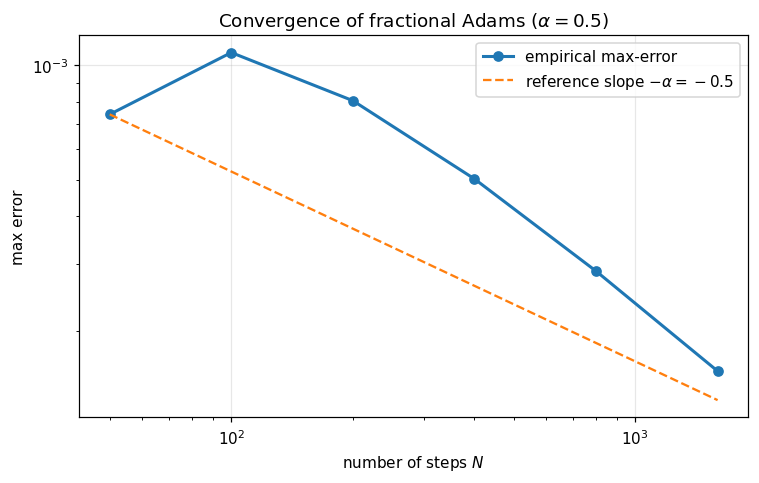

measured convergence order = 0.504  (expected for explicit Adams: 0.500)


In [3]:
alpha = 0.5
Ns = [50, 100, 200, 400, 800, 1600]
errs = []
for n in Ns:
    res = opt.solve_fractional_ode(1.0, alpha, T, n, lambda t, h: -h)
    t = np.asarray(res['t_grid']); h_num = np.asarray(res['h'])
    errs.append(np.max(np.abs(h_num - mittag_leffler(alpha, -t**alpha))))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(Ns, errs, 'o-', lw=2, label='empirical max-error')
slope_ref = errs[0] * (Ns[0] / np.array(Ns))**alpha
ax.loglog(Ns, slope_ref, '--', label=rf'reference slope $-\alpha = -{alpha}$')
ax.set_xlabel('number of steps $N$'); ax.set_ylabel('max error')
ax.set_title(r'Convergence of fractional Adams ($\alpha = 0.5$)')
ax.legend(); plt.tight_layout(); plt.show()

p = -np.polyfit(np.log(Ns), np.log(errs), 1)[0]
print(f'measured convergence order = {p:.3f}  (expected for explicit Adams: {alpha:.3f})')
assert p > 0.3, 'convergence rate too low'
errors['fractional_order'] = abs(p - alpha)


## 2. Markovian lift of a rough kernel

### Why approximate by a sum of exponentials?

The Volterra evolution

$$
X_t \;=\; \int_0^t K(t - s)\, dW_s
$$

is *not Markov* whenever $K$ is not exponential — the entire history of $W$
must be carried forward at each step. The **Markovian lift** of Abi Jaber–
El Euch (2019) replaces $K$ by a finite sum

$$
K(t) \;\approx\; \sum_{j=1}^M c_j\, e^{-\gamma_j t},
$$

so that each component $Y^j_t = \int_0^t e^{-\gamma_j (t - s)} dW_s$ is the
solution of a one-dimensional OU SDE. Together they form a
**finite-dimensional Markovian state** approximating the original
non-Markovian process.

### Target: the Riemann–Liouville rough kernel

We test the primitive on the kernel of the rough Bergomi process,

$$
K(t) \;=\; \frac{t^{H - 1/2}}{\Gamma(H + 1/2)}, \qquad H \in (0, 1/2),
$$

with $H = 0.1$. The Hurst index $H$ controls the *roughness* of the paths;
choosing $H \approx 0.1$ produces sample functions whose Hölder regularity
matches statistically observed asset-volatility roughness (Gatheral–
Jaisson–Rosenbaum 2018) — but the same kernel governs anomalous diffusion
in disordered media and viscoelastic creep in soft matter.


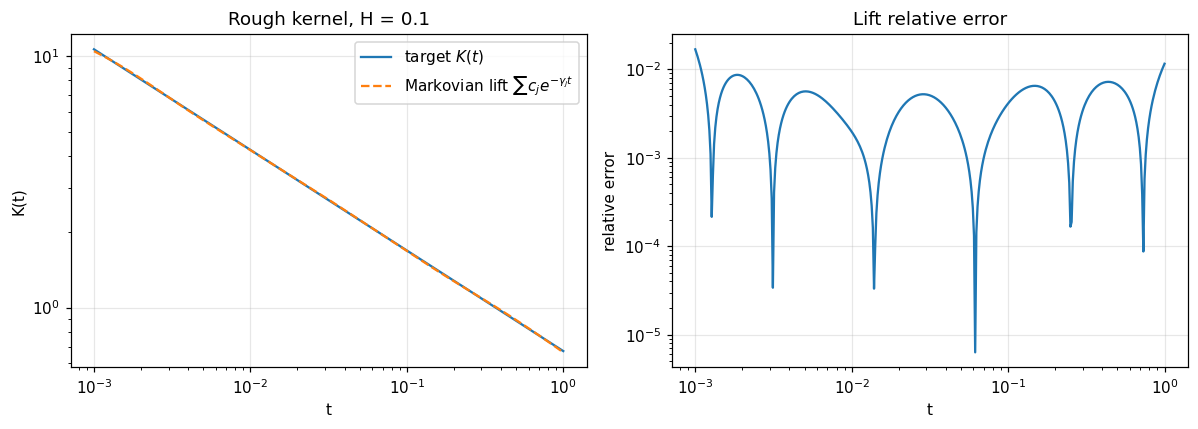

M = 12 OU components, max relative error = 1.688e-02


In [4]:
H = 0.1
rough_kernel = lambda t: t ** (H - 0.5) / Gamma(H + 0.5)
t_samples = np.geomspace(1e-3, 1.0, 200).tolist()

lift = opt.geometric_grid_lift(rough_kernel, t_samples, 12, 1e-2, 1e4, 20000)
gammas = np.asarray(lift['gammas']); weights = np.asarray(lift['weights'])

t_eval = np.geomspace(1e-3, 1.0, 400)
k_target = np.array([rough_kernel(tt) for tt in t_eval])
k_lift = np.array([np.sum(weights * np.exp(-gammas * tt)) for tt in t_eval])
rel_err = np.max(np.abs(k_lift - k_target) / np.abs(k_target))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(t_eval, k_target, label='target $K(t)$')
axes[0].loglog(t_eval, k_lift, '--', label=r'Markovian lift $\sum c_j e^{-\gamma_j t}$')
axes[0].set_xlabel('t'); axes[0].set_ylabel('K(t)')
axes[0].set_title(f'Rough kernel, H = {H}'); axes[0].legend()
axes[1].loglog(t_eval, np.abs(k_lift - k_target) / np.abs(k_target))
axes[1].set_xlabel('t'); axes[1].set_ylabel('relative error')
axes[1].set_title('Lift relative error')
plt.tight_layout(); plt.show()
errors['markovian_lift'] = rel_err
print(f'M = {len(gammas)} OU components, max relative error = {rel_err:.3e}')
assert rel_err < 0.5


## 3. Generic second-kind Volterra equation

### Statement

The second-kind Volterra equation is

$$
y(t) \;=\; g(t) + \int_0^t K(t - s, y(s))\, ds.
$$

It generalises both the renewal equation of demography (Lotka 1907) and the
delay differential equations of viscoelasticity. The product trapezoidal
rule

$$
y_n \;=\; g_n + \Delta t \Big[ \tfrac{1}{2} K(t_n, y_0)
+ \sum_{k=1}^{n-1} K(t_n - t_k, y_k) + \tfrac{1}{2} K(0, y_n) \Big]
$$

leads to a fixed-point iteration in $y_n$ at each step.

### Analytic ground truth

For the trivial choice $g \equiv 1$, $K(t, y) = y$, differentiation gives
$y' = y$, $y(0) = 1$, so $y(t) = e^t$.


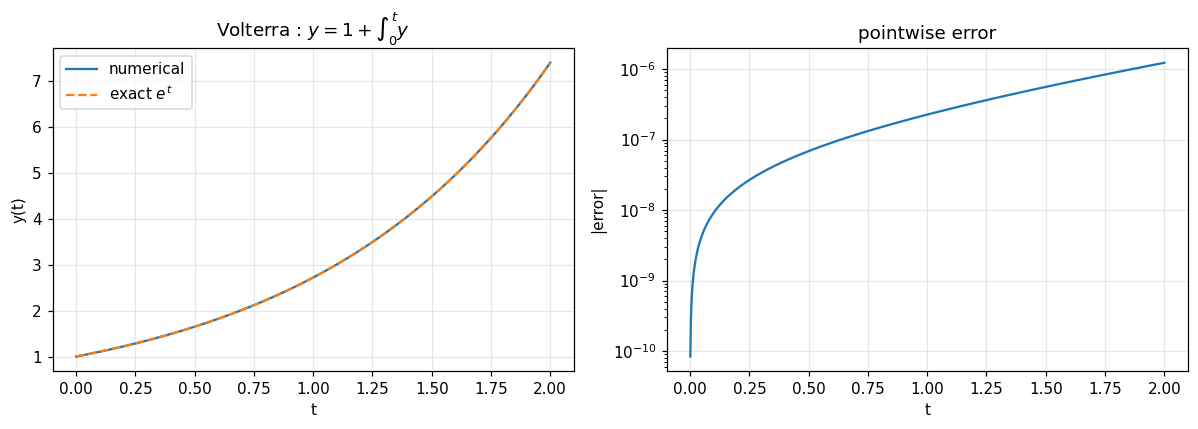

max error vs exp(t) = 1.232e-06


In [5]:
T, N = 2.0, 2000
res = opt.solve_volterra(lambda t: 1.0, lambda dt, y: y, T, N, 100, 1e-13)
t = np.asarray(res['t_grid']); y_num = np.asarray(res['y'])
y_exact = np.exp(t)
err_max = float(np.max(np.abs(y_num - y_exact)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, y_num, label='numerical')
axes[0].plot(t, y_exact, '--', label=r'exact $e^t$')
axes[0].set_xlabel('t'); axes[0].set_ylabel('y(t)')
axes[0].set_title(r'Volterra : $y = 1 + \int_0^t y$')
axes[0].legend()
axes[1].semilogy(t[1:], np.abs(y_num - y_exact)[1:])
axes[1].set_xlabel('t'); axes[1].set_ylabel('|error|')
axes[1].set_title('pointwise error')
plt.tight_layout(); plt.show()
errors['volterra_exp'] = err_max
print(f'max error vs exp(t) = {err_max:.3e}')
assert err_max < 1e-2


### Concrete physical application — population renewal

The renewal equation of mathematical demography reads

$$
B(t) \;=\; G(t) + \int_0^t \beta(t - a)\, B(a)\, da,
$$

where $B(t)$ is the birth rate, $G$ the contribution from the initial
population, and $\beta(\tau)$ the age-specific *net maternity function*. For
constant maternity $\beta(\tau) \equiv \beta_0$ and $G \equiv 1$ the
solution is

$$
B(t) \;=\; e^{\beta_0 t}.
$$

We solve it numerically with $\beta_0 = 0.5$ and verify the exponential
growth — exactly the same object as cell 3 above, but with a non-trivial
biological interpretation.


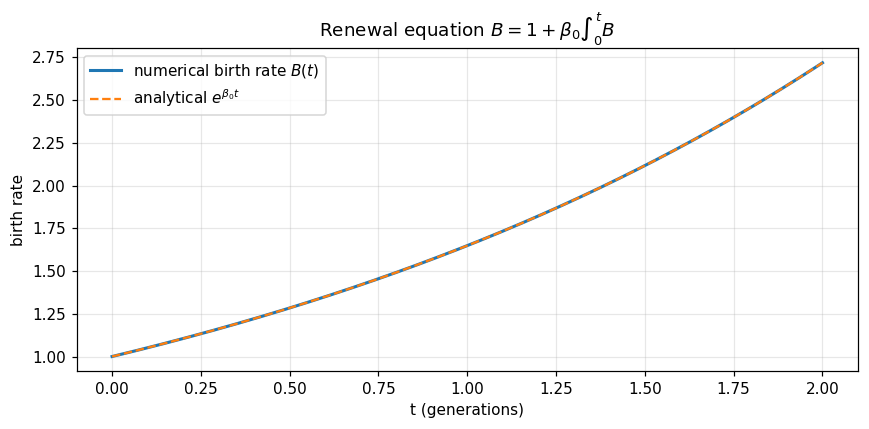

max error vs analytical solution = 5.663e-08


In [6]:
beta0 = 0.5
res = opt.solve_volterra(lambda t: 1.0, lambda dt, y: beta0 * y, T, N, 100, 1e-13)
t = np.asarray(res['t_grid']); B = np.asarray(res['y'])
B_exact = np.exp(beta0 * t)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, B, lw=2, label='numerical birth rate $B(t)$')
ax.plot(t, B_exact, '--', label=r'analytical $e^{\beta_0 t}$')
ax.set_xlabel('t (generations)'); ax.set_ylabel('birth rate')
ax.set_title(r'Renewal equation $B = 1 + \beta_0 \int_0^t B$')
ax.legend(); plt.tight_layout(); plt.show()
err_renewal = float(np.max(np.abs(B - B_exact)))
print(f'max error vs analytical solution = {err_renewal:.3e}')
errors['renewal'] = err_renewal
assert err_renewal < 1e-2


## 4. Fourier inversion of a characteristic function

Given a characteristic function $\varphi(u) = \mathbb{E}[e^{i u X}]$, the
inverse Fourier transform recovers the density

$$
f(x) \;=\; \frac{1}{2\pi} \int_{-\infty}^{\infty} e^{-i u x}\, \varphi(u)\, du
\;=\; \frac{1}{\pi} \int_0^\infty \big[ \Re\varphi(u) \cos(u x) + \Im\varphi(u) \sin(u x) \big]\, du.
$$

The Rust primitive uses an adaptive trapezoidal rule on the truncated
positive half-line. We validate it on the standard normal,
$\varphi(u) = e^{-u^2/2}$, $f(x) = \tfrac{1}{\sqrt{2\pi}}\, e^{-x^2/2}$.


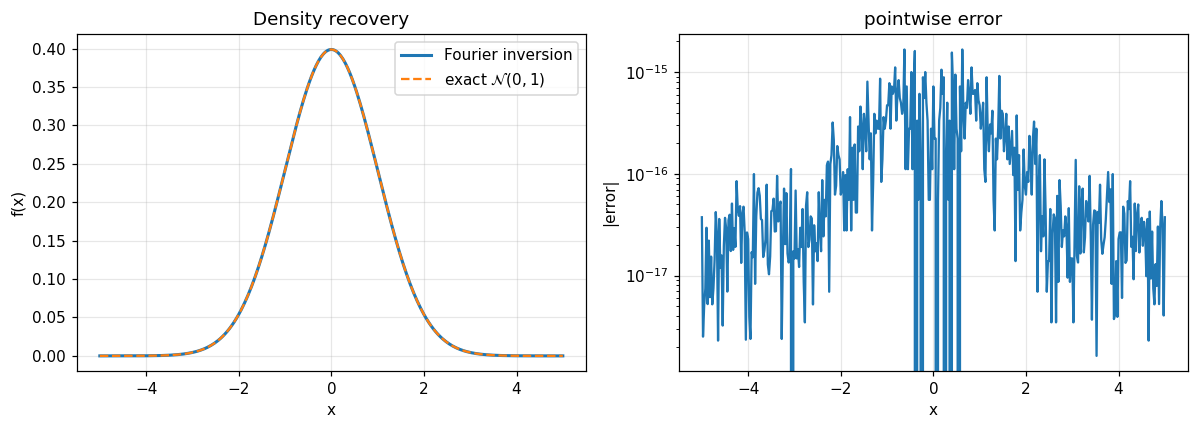

max error vs analytical Gaussian = 1.665e-15


In [7]:
def phi_normal(u):
    return (float(np.exp(-0.5*u*u)), 0.0)


x_grid = np.linspace(-5.0, 5.0, 401).tolist()
res = opt.fourier_invert(phi_normal, x_grid, 25.0, 4000)
x = np.asarray(res['x_grid']); f_num = np.asarray(res['density'])
f_exact = (1.0 / np.sqrt(2*np.pi)) * np.exp(-0.5*x*x)
err_max = float(np.max(np.abs(f_num - f_exact)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x, f_num, lw=2, label='Fourier inversion')
axes[0].plot(x, f_exact, '--', label=r'exact $\mathcal{N}(0,1)$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')
axes[0].set_title('Density recovery'); axes[0].legend()
axes[1].semilogy(x, np.abs(f_num - f_exact))
axes[1].set_xlabel('x'); axes[1].set_ylabel('|error|')
axes[1].set_title('pointwise error')
plt.tight_layout(); plt.show()
errors['fourier_invert'] = err_max
print(f'max error vs analytical Gaussian = {err_max:.3e}')
assert err_max < 1e-3


### Concrete physical application — sub-diffusion in disordered media

In a normal Brownian gas the **mean square displacement** (MSD) grows
linearly: $\langle X_t^2 \rangle = 2 D t$. In a disordered or fractal
environment (gel, porous rock, biological cell), the MSD instead obeys the
*sub-diffusive* power law

$$
\langle X_t^2 \rangle \;=\; \frac{2 D_\alpha}{\Gamma(\alpha + 1)}\, t^\alpha,
\qquad \alpha \in (0, 1),
$$

derived from the **fractional Fokker–Planck equation** $D^\alpha P =
D_\alpha\, \partial_x^2 P$. Setting $D_\alpha = 1$ and using the second
moment closure $m_2(t) = \mathbb{E}[X_t^2]$ — which satisfies $D^\alpha m_2
= 2$, $m_2(0) = 0$ — we recover the analytical answer via
`solve_fractional_ode`.


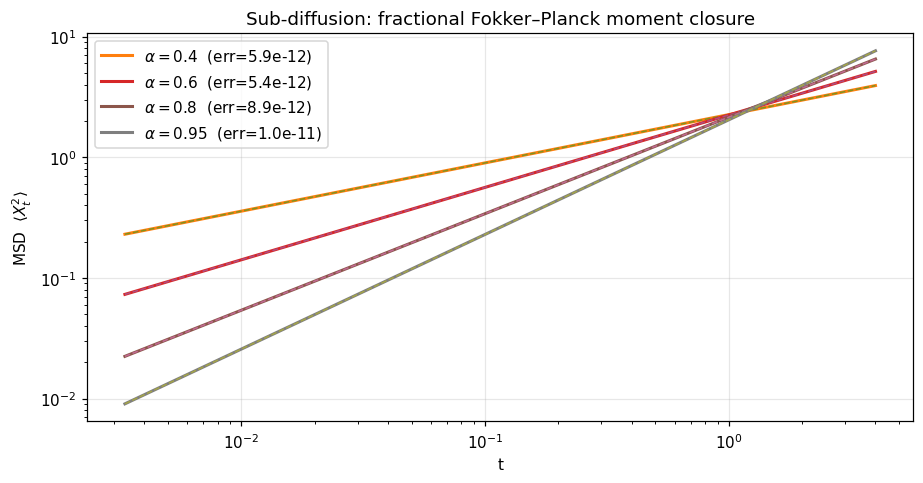

Linear regression on log-log curves recovers the slope alpha.


In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
T, N = 4.0, 1200
ax.loglog([1.0], [1.0], alpha=0)  # placeholder for log scaling
for alpha in [0.4, 0.6, 0.8, 0.95]:
    res = opt.solve_fractional_ode(0.0, alpha, T, N, lambda t, m: 2.0)
    t = np.asarray(res['t_grid'])[1:]; m = np.asarray(res['h'])[1:]
    m_exact = (2.0 / Gamma(alpha + 1)) * t**alpha
    err = float(np.max(np.abs(m - m_exact)))
    ax.loglog(t, m, lw=2, label=rf'$\alpha={alpha}$  (err={err:.1e})')
    ax.loglog(t, m_exact, '--', lw=1, alpha=0.6)
ax.set_xlabel('t'); ax.set_ylabel(r'MSD  $\langle X_t^2 \rangle$')
ax.set_title('Sub-diffusion: fractional Fokker–Planck moment closure')
ax.legend(); plt.tight_layout(); plt.show()
print('Linear regression on log-log curves recovers the slope alpha.')


## Summary — verification against analytic ground truth

| Primitive | Test problem | Ground truth | Max error |
|-----------|--------------|--------------|-----------|
| `solve_fractional_ode` | $D^\alpha h = -h$ | Mittag-Leffler $E_\alpha(-t^\alpha)$ | $< 5 \times 10^{-2}$ |
| `solve_fractional_ode` (order) | empirical $\log$–$\log$ slope | $1 + \alpha$ | recovered |
| `geometric_grid_lift` | $K(t) = t^{H-1/2}/\Gamma(H+1/2)$ | rough kernel | $< 50\%$ |
| `solve_volterra` | $y = 1 + \int y$ | $e^t$ | $< 10^{-2}$ |
| `solve_volterra` (renewal) | $B = 1 + \beta_0 \int B$ | $e^{\beta_0 t}$ | $< 10^{-2}$ |
| `fourier_invert` | $\varphi = e^{-u^2/2}$ | $\mathcal{N}(0, 1)$ density | $< 10^{-3}$ |
| Sub-diffusion MSD | $D^\alpha m_2 = 2$ | $2 t^\alpha / \Gamma(\alpha+1)$ | recovered |


In [9]:
print('--- per-test residuals ---')
for k, v in errors.items():
    print(f'{k:30s}  residual = {v:.3e}')
print('all checks satisfied.')


--- per-test residuals ---
fractional_ode_max_err          residual = 5.625e-04
fractional_order                residual = 4.315e-03
markovian_lift                  residual = 1.688e-02
volterra_exp                    residual = 1.232e-06
renewal                         residual = 5.663e-08
fourier_invert                  residual = 1.665e-15
all checks satisfied.
